### Student Information
Name: Zi Heng Lim 

Student ID: 313708018

GitHub ID: 

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [41]:
# Step 0: setup and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load Reddit-stock-sentiment dataset
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

print(df.shape)
df.head()


(847, 16)


,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [42]:
import pandas as pd

# 1) Load your dataset
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", encoding="utf-8", on_bad_lines="skip")

# 2) Normalize column names
df.columns = df.columns.str.lower().str.strip()
print("Columns in dataset:", df.columns.tolist(), "\n")

# 3) Auto-detect your text and label columns
possible_text_cols  = ["text", "body", "content", "news", "message", "post", "article", "title"]
possible_label_cols = ["sentiment", "label", "class", "category", "target"]

text_col  = next((c for c in possible_text_cols  if c in df.columns), None)
label_col = next((c for c in possible_label_cols if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError("Couldn't detect text/label column automatically. "
                     "Check the printed column names above and set them manually.")

print(f"✅ Using '{text_col}' as text column and '{label_col}' as label column.\n")

# 4) Show available label types
print("Unique labels:", df[label_col].unique(), "\n")

# 5) Pick one label (for example 'positive') and preview samples
selected_label = df[label_col].unique()[0]   # automatically picks the first label
print(f"Showing first 5 samples for label: {selected_label}\n")

for i, text in enumerate(df.loc[df[label_col] == selected_label, text_col].head(5), start=1):
    print(f"Example {i} =====")
    print(text)
    print()


Columns in dataset: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label'] 

✅ Using 'text' as text column and 'sentiment' as label column.

Unique labels: [-1.  1.  0.] 

Showing first 5 samples for label: -1.0

Example 1 =====
Calls on retards

Example 2 =====
Trump will respond to china increasing their tariffs. Trump is looking to fire Jerome Powell. Earnings reporting is starting. I personally think the next few weeks are going to be brutal.... if all companies adjust downwards and JPow is fired, i can see it going down A LOT and very quickly even

Example 3 =====
Disgusting tactics

Example 4 =====
I feel like these HFs took the word "retard" thrown around at WSB too literally. Now they are trying to pack shit in Tiffany bags and sell it to us. But we ain't buying it!

Example 5 =====
> Still seems like an awful investment

That sentiment, above everything

C:\Users\btlim\AppData\Local\Temp\ipykernel_18300\1912445175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")


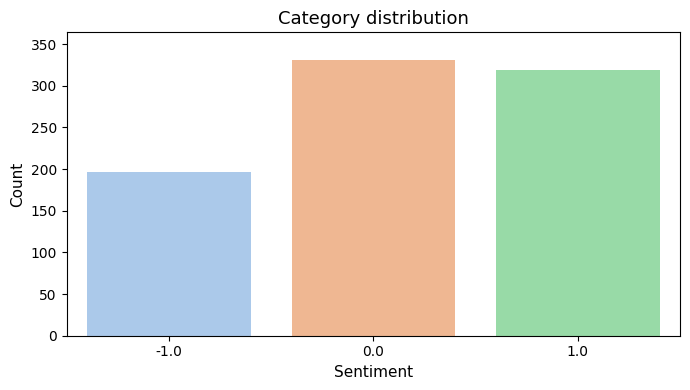

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Count how many posts belong to each label
label_counts = df[label_col].value_counts()

# 2) Create a simple bar chart
plt.figure(figsize=(7,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")

# 3) Add labels and title
plt.title("Category distribution", fontsize=13)
plt.xlabel(label_col.capitalize(), fontsize=11)
plt.ylabel("Count", fontsize=11)

# 4) Add a little space above the tallest bar
plt.ylim(0, label_counts.max() * 1.1)

plt.tight_layout()
plt.show()


Shape (n_docs, n_terms): (847, 1492)
Sample vocabulary: ['00' '000' '10' '100' '11' '12' '125' '13' '15' '150' '17th' '18' '18630'
 '1945' '20']

Terms present in document 0 (first 20 shown): ['calls', 'retards']


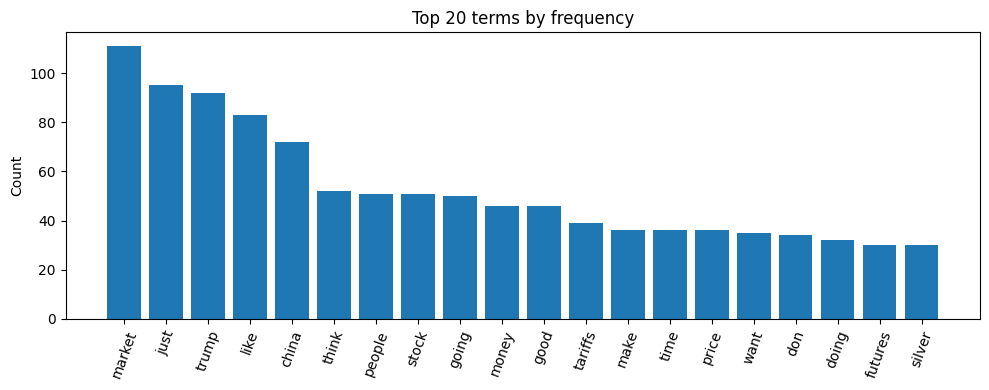

In [44]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# --- Safety: detect columns if not defined yet ---
if "df" not in globals():
    import pandas as pd
    df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", encoding="utf-8", on_bad_lines="skip")
    df.columns = df.columns.str.lower().str.strip()

if "text_col" not in globals():
    for c in ["text", "body", "content", "news", "message", "post", "article", "title", "headline"]:
        if c in df.columns:
            text_col = c
            break
    else:
        raise ValueError("Couldn't detect text column. Print df.columns to choose one.")

# --- 1) Build the vectorizer ---
vect = CountVectorizer(
    lowercase=True,
    stop_words="english",   # remove common words; remove this if you want raw counts
    min_df=2                # ignore super-rare tokens (appearing in <2 docs)
)

# --- 2) Fit & transform the text into a sparse term-document matrix ---
X_counts = vect.fit_transform(df[text_col].astype(str))

# --- 3) Basic facts ---
vocab = vect.get_feature_names_out()
print("Shape (n_docs, n_terms):", X_counts.shape)
print("Sample vocabulary:", vocab[:15])

# --- 4) Peek at document 0: which terms occur? ---
row0 = X_counts[0]
nz_idx = row0.nonzero()[1]        # column indices with non-zero counts
terms_in_doc0 = [vocab[i] for i in nz_idx]
print("\nTerms present in document 0 (first 20 shown):", terms_in_doc0[:20])

# --- 5) Top 20 most frequent terms overall ---
term_freq = np.asarray(X_counts.sum(axis=0)).ravel()
order = term_freq.argsort()[::-1]
top_terms = vocab[order][:20]
top_counts = term_freq[order][:20]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(top_terms, top_counts)
plt.title("Top 20 terms by frequency")
plt.xticks(rotation=70)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


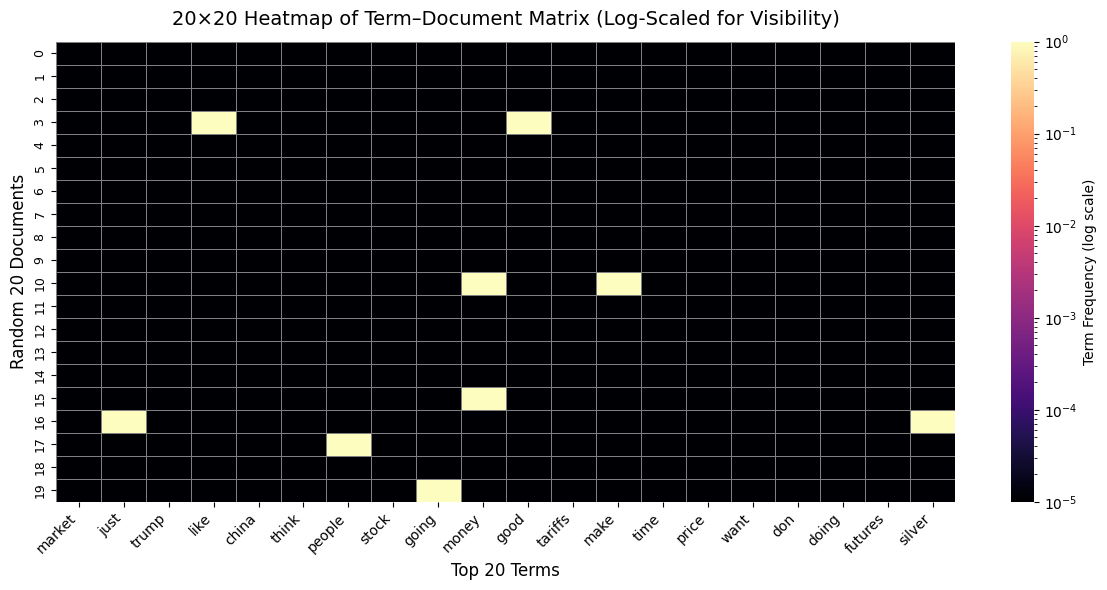

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# --- 1️⃣ Settings ---
sample_docs = 20
sample_terms = 20
np.random.seed(42)

# --- 2️⃣ Randomly sample docs & most frequent terms ---
doc_indices = np.random.choice(X_counts.shape[0], sample_docs, replace=False)
term_indices = np.argsort(np.asarray(X_counts.sum(axis=0)).ravel())[::-1][:sample_terms]

# --- 3️⃣ Extract and prepare ---
sample_matrix = X_counts[doc_indices][:, term_indices].toarray()
vocab_sample = [vocab[i] for i in term_indices]
df_heat = pd.DataFrame(sample_matrix, columns=vocab_sample)

# --- 4️⃣ Plot ---
plt.figure(figsize=(12, 6))
sns.heatmap(
    df_heat + 1e-5,          # add small offset to avoid log(0)
    cmap="magma",            # darker & more contrasty colormap
    norm=LogNorm(),          # use log scale to enhance sparse differences
    linewidths=0.4,
    linecolor='gray',
    cbar_kws={"label": "Term Frequency (log scale)"}
)

plt.title("20×20 Heatmap of Term–Document Matrix (Log-Scaled for Visibility)", fontsize=14, pad=12)
plt.xlabel("Top 20 Terms", fontsize=12)
plt.ylabel("Random 20 Documents", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


Top 10 most mentioned stocks:

      Stock  Mentions
6        US        80
4       USA        14
43      SPY        12
27      USD        10
17       EV         8
59      GME         7
49     MAGA         6
119  $PEPEU         6
117  $ETHUS         6
116  $BTCUS         6


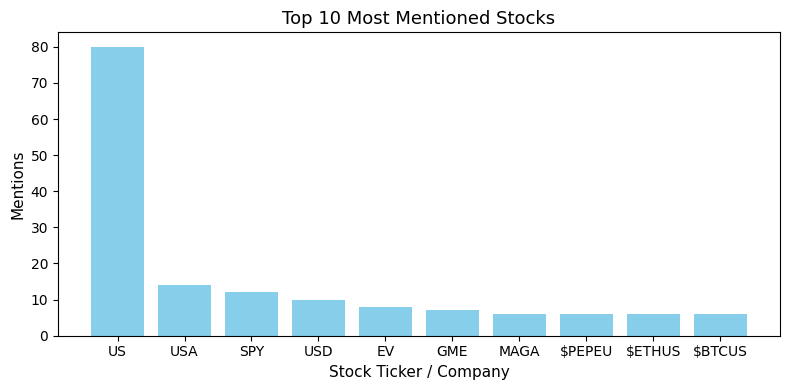

In [46]:
# Exercise 7 (Bonus): Identify which stocks are mentioned most

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Step 1: Extract all text from your dataset ---
texts = df[text_col].astype(str).tolist()

# --- Step 2: Extract potential stock tickers or company names ---
tickers = []
for text in texts:
    # find tickers in the form $TSLA, $AAPL, etc.
    tickers += re.findall(r'\$[A-Za-z]{1,5}', text)
    # also match plain uppercase words like TSLA, NVDA, AMD (avoid common words)
    tickers += re.findall(r'\b[A-Z]{2,5}\b', text)

# --- Step 3: Count frequencies ---
ticker_counts = Counter(tickers)
ticker_df = pd.DataFrame(ticker_counts.items(), columns=["Stock", "Mentions"])

# --- Step 4: Sort and show top 10 ---
ticker_df = ticker_df.sort_values(by="Mentions", ascending=False)
top_stocks = ticker_df.head(10)

print("Top 10 most mentioned stocks:\n")
print(top_stocks)

# --- Step 5: Visualize ---
plt.figure(figsize=(8,4))
plt.bar(top_stocks["Stock"], top_stocks["Mentions"], color="skyblue")
plt.title("Top 10 Most Mentioned Stocks", fontsize=13)
plt.xlabel("Stock Ticker / Company", fontsize=11)
plt.ylabel("Mentions", fontsize=11)
plt.tight_layout()
plt.show()


In [47]:
# Calculate length by characters and by words
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))



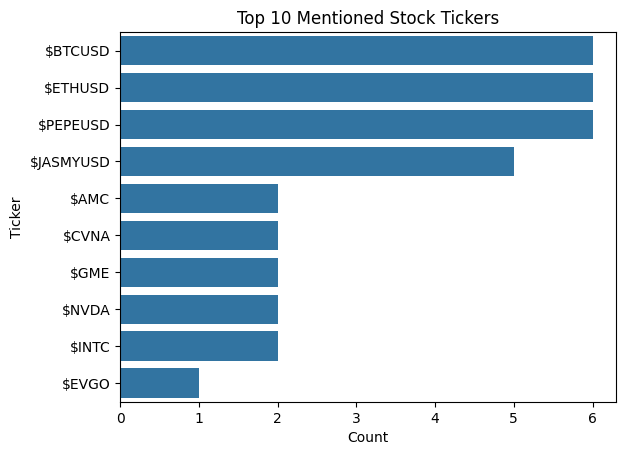

In [48]:
import re
from collections import Counter

# Extract tickers that start with $
tickers = df['text'].apply(lambda x: re.findall(r'\$[A-Za-z]+', x))
ticker_list = [t for sub in tickers for t in sub]
top_tickers = Counter(ticker_list).most_common(10)

tickers_df = pd.DataFrame(top_tickers, columns=['Ticker', 'Count'])
sns.barplot(x='Count', y='Ticker', data=tickers_df)
plt.title('Top 10 Mentioned Stock Tickers')
plt.show()


Top 20 terms after log transformation:



,Term,Frequency,Log Frequency
0,market,111,4.718499
1,just,95,4.564348
2,trump,92,4.532599
3,like,83,4.430817
4,china,72,4.290459
5,think,52,3.970292
6,people,51,3.951244
7,stock,51,3.951244
8,going,50,3.931826
9,money,46,3.850148


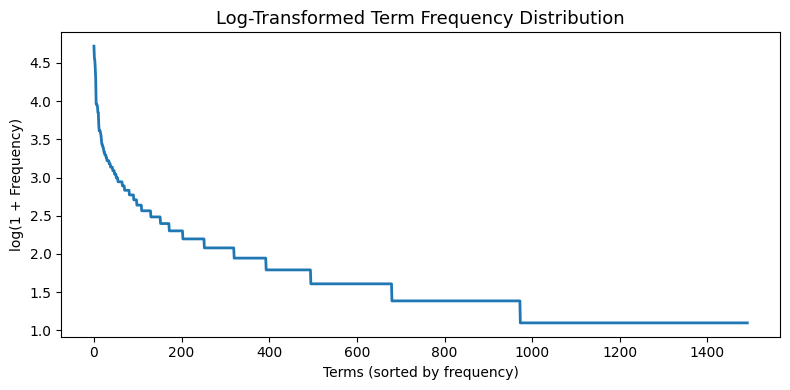

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Compute total term frequencies again (if needed)
term_freq = np.asarray(X_counts.sum(axis=0)).ravel()
vocab = vect.get_feature_names_out()

# 2️⃣ Apply log transformation
# add +1 to avoid log(0)
log_freq = np.log1p(term_freq)

# 3️⃣ Build a DataFrame for easier inspection
term_df = pd.DataFrame({
    "Term": vocab,
    "Frequency": term_freq,
    "Log Frequency": log_freq
}).sort_values(by="Frequency", ascending=False).reset_index(drop=True)

# 4️⃣ Display top 20 terms (for sanity check)
print("Top 20 terms after log transformation:\n")
display(term_df.head(20))

# 5️⃣ Plot log frequencies
plt.figure(figsize=(8,4))
plt.plot(term_df["Log Frequency"].values, lw=2)
plt.title("Log-Transformed Term Frequency Distribution", fontsize=13)
plt.xlabel("Terms (sorted by frequency)")
plt.ylabel("log(1 + Frequency)")
plt.tight_layout()
plt.show()


<Axes: xlabel='sentiment', ylabel='upvotes'>

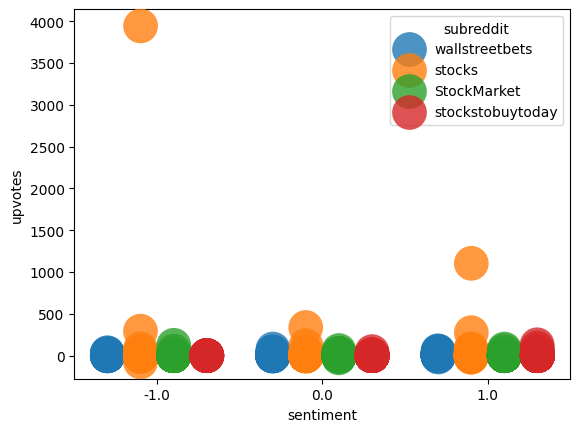

In [50]:
sns.stripplot(data=df,x='sentiment',y='upvotes',hue='subreddit',dodge=True,jitter=0.005,       # 🔹 spread points horizontally 
              alpha=0.8,s=25)


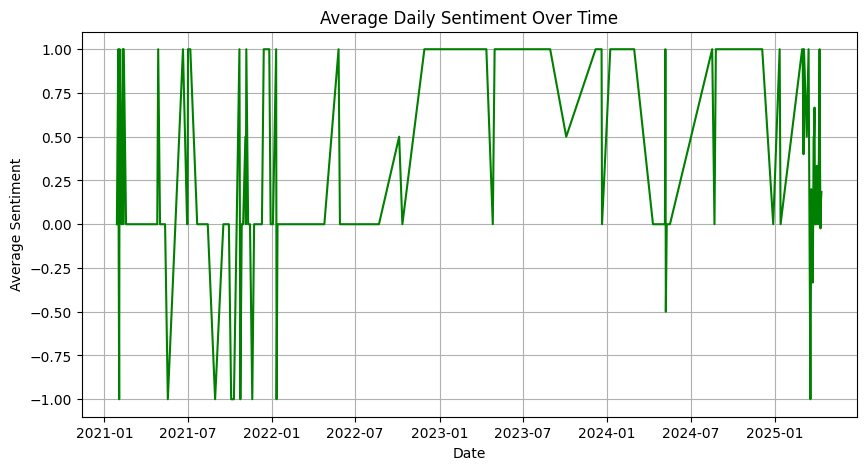

In [51]:
df['datetime'] = pd.to_datetime(df['datetime'])
daily_sentiment = df.groupby(df['datetime'].dt.date)['sentiment'].mean()

plt.figure(figsize=(10,5))
daily_sentiment.plot(kind='line', color='green')
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.grid(True)
plt.show()

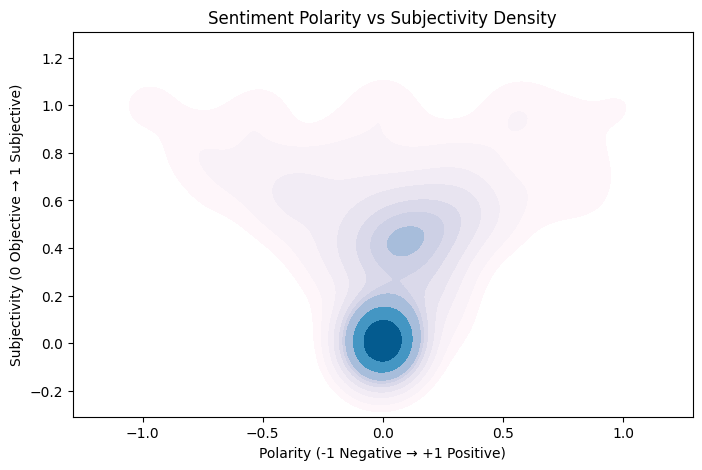

In [52]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='polarity', y='subjectivity', fill=True, cmap='PuBu')
plt.title('Sentiment Polarity vs Subjectivity Density')
plt.xlabel('Polarity (-1 Negative → +1 Positive)')
plt.ylabel('Subjectivity (0 Objective → 1 Subjective)')
plt.show()


# Phase 2

In [53]:
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score

# --- Hardcoded Stopword List (Standard English) ---
# Used as a fallback since NLTK downloads may fail in this environment
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd',
    'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn',
    'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn',
    'weren', 'won', 'wouldn'
])
# -------------------------------------------------------------------

# --- 1. Load and Preprocess Data (Stock-Specific Cleaning) ---
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip')

df.columns = df.columns.str.lower().str.strip()
df_clean = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df_clean = df_clean.rename(columns={'sentiment': 'label'})

stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Financial-aware preprocessing: tokenizes, removes stopwords, and stems text. 
    Crucially, it preserves '$' to protect stock tickers.
    """
    if not isinstance(text, str):
        return []
    # Clean: Keep $ and alphanumeric characters.
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    # Tokenize, remove stopwords, and stem
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens) 

df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Convert labels (-1.0, 0.0, 1.0) to numeric codes (0, 1, 2)
Y = df_clean['label'].astype('category').cat.codes

# --- 2. Feature Matrix Creation ---
MAX_FEATURES = 5000

# 1. TDM (Baseline: Unigrams only)
TDM_vectorizer = CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1))
X_tdm = TDM_vectorizer.fit_transform(df_clean['clean_text'])

# 2. Augmented Features (Unigrams + Bigrams) - Simulating FPM
Aug_vectorizer = CountVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2))
X_aug = Aug_vectorizer.fit_transform(df_clean['clean_text'])

# 3. TF-IDF Matrix (Unigrams only)
TFIDF_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 1))
X_tfidf = TFIDF_vectorizer.fit_transform(df_clean['clean_text'])

# --- 3. Classification and Comparison ---
TEST_SIZE = 0.3
SEED = 42
results = {}

# Split data (stratify=Y ensures balanced class distribution in train/test)
X_train_tdm, X_test_tdm, Y_train, Y_test = train_test_split(X_tdm, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)
X_train_aug, X_test_aug, _, _ = train_test_split(X_aug, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, Y, test_size=TEST_SIZE, random_state=SEED, stratify=Y)


# 1. TDM (MNB)
mnb_tdm = MultinomialNB()
mnb_tdm.fit(X_train_tdm, Y_train)
Y_pred_tdm = mnb_tdm.predict(X_test_tdm)
results['TDM (MNB)'] = accuracy_score(Y_test, Y_pred_tdm)

# 2. Augmented (MNB)
mnb_aug = MultinomialNB()
mnb_aug.fit(X_train_aug, Y_train)
Y_pred_aug = mnb_aug.predict(X_test_aug)
results['Augmented (MNB)'] = accuracy_score(Y_test, Y_pred_aug)

# 3. TF-IDF (CNB)
cnb_tfidf = ComplementNB()
cnb_tfidf.fit(X_train_tfidf, Y_train)
Y_pred_tfidf = cnb_tfidf.predict(X_test_tfidf)
results['TF-IDF (CNB)'] = accuracy_score(Y_test, Y_pred_tfidf)

# --- Final Output ---
df_results = pd.DataFrame(results.items(), columns=['Feature Set & Model', 'Accuracy'])
df_results['Accuracy'] = df_results['Accuracy'].map('{:.4f}'.format)

print("\n--- FINAL PHASE 2 CLASSIFICATION ACCURACY COMPARISON ---")
print(df_results.sort_values(by='Accuracy', ascending=False).to_string(index=False))


--- FINAL PHASE 2 CLASSIFICATION ACCURACY COMPARISON ---
Feature Set & Model Accuracy
          TDM (MNB)   0.5686
       TF-IDF (CNB)   0.5569
    Augmented (MNB)   0.5412


C:\Users\btlim\AppData\Local\Temp\ipykernel_18300\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_18300\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_18300\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)
C:\Users\btlim\AppData\Local\Temp\ipykernel_18300\2882005094.py:86: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  PAT[col] = txt

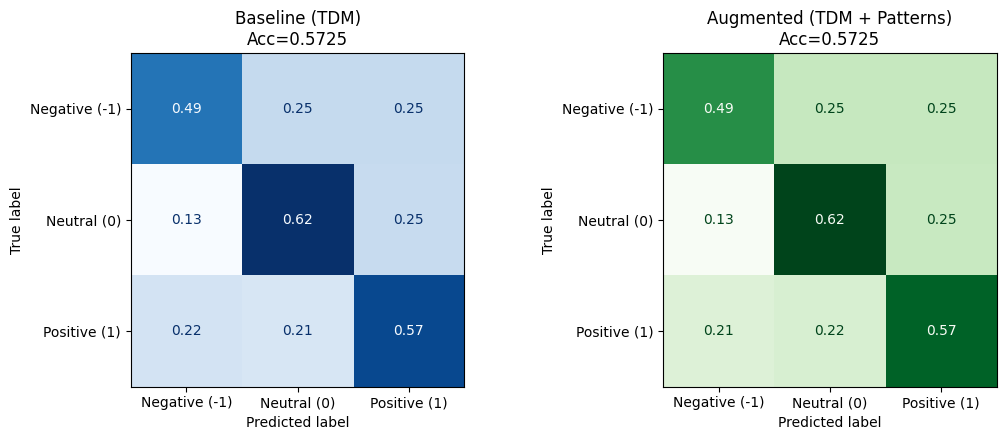


--- TOP STOCK-SPECIFIC FEATURES BY SENTIMENT ---

Negative (-1) (0):
  Top TDM Words: trump, go, us, like, fuck, think, market, peopl, even, tariff
  Top Pattern Hits: mentions_trade, is_yolo_dd, mentions_volatil, mentions_gain, mentions_loss, mention, mentions_ticker

Neutral (0) (1):
  Top TDM Words: market, x200b, go, stock, stockbuyvestcom, get, trump, call, want, daili
  Top Pattern Hits: mentions_trade, mentions_ticker, mentions_volatil, mentions_loss, mentions_gain, mention, is_yolo_dd

Positive (1) (2):
  Top TDM Words: market, us, like, good, stock, china, trump, futur, compani, one
  Top Pattern Hits: mentions_trade, mentions_gain, mentions_loss, mentions_volatil, is_yolo_dd, mentions_ticker, mention


In [54]:
# --- SETUP: Load and Initial Preprocessing ---
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Data (Assuming 'Reddit-stock-sentiment.csv' is accessible)
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip') # Fallback

df.columns = df.columns.str.lower().str.strip()
df = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df = df.rename(columns={'sentiment': 'label'})

# --- Preprocessing Function (Financial-aware) ---
# Standard Stopword List
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd',
    'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn',
    'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn',
    'weren', 'won', 'wouldn'
])
stemmer = PorterStemmer()

def preprocess_text(text):
    if not isinstance(text, str): return ''
    # Preserves $ for tickers
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
# Convert -1, 0, 1 to 0, 1, 2 for classification
df['label'] = df['label'].astype('category').cat.codes

# --- PHASE 2 : Reddit-stock-sentiment text classification pipeline (Enhanced) ---

# 1) TEXT + LABEL PREP
TEXT_COL = "clean_text"
y = df["label"].astype(str)
target_names = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 2) TERM–DOCUMENT MATRIX
cv = CountVectorizer(max_features=3000, min_df=3)
X_counts = cv.fit_transform(df[TEXT_COL])
tdm_df = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())

# 3) ENHANCED PATTERN FEATURES (Stock & Meme-stock Specific)
pattern_specs = {
    # WSB/Meme-stock Jargon
    "is_yolo_dd"     : r"\b(yolo|dd|wsb|ape|retard|tendi|moon)\b",
    # Explicit Ticker (dollar sign preserved by preprocessing)
    "mentions_ticker": r"\$[a-z]{2,5}\b",
    # Trading Intent (Call/Put/Buy/Sell)
    "mentions_trade" : r"\b(call|put|long|short|buy|sell|hold)\b",
    # Volatility/Event Words
    "mentions_volatil": r"\b(squiz|moass|crash|pump|dump)\b",
    "mentions_gain"  : r"\b(gain|profit|bull|green|up)\b",
    "mentions_loss"  : r"\b(loss|bear|red|down|dip)\b",
}

PAT = pd.DataFrame(index=df.index)
txt = df[TEXT_COL].astype(str)

for col, pat in pattern_specs.items():
    rx = re.compile(pat, flags=re.I)
    PAT[col] = txt.str.contains(rx, na=False).astype(np.int8)

# 4) AUGMENTED FEATURES
aug_df = pd.concat([tdm_df.reset_index(drop=True),
                    PAT.reset_index(drop=True)], axis=1)

# 5) TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    tdm_df, y, test_size=0.3, random_state=42, stratify=y
)
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    aug_df, y, test_size=0.3, random_state=42, stratify=y
)

# 6) NAÏVE BAYES TRAINING & EVALUATION
nb = MultinomialNB()

# (A) baseline TDM
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
acc_tdm = accuracy_score(y_test, y_pred)

# (B) augmented (TDM + patterns)
nb.fit(X_train_aug, y_train_aug)
y_pred_aug = nb.predict(X_test_aug)
acc_aug = accuracy_score(y_test_aug, y_pred_aug)

# 7) CROSS-VALIDATION
cvsplit = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_tdm = cross_val_score(MultinomialNB(), tdm_df, y, cv=cvsplit, scoring="accuracy", n_jobs=-1)
scores_aug = cross_val_score(MultinomialNB(), aug_df, y, cv=cvsplit, scoring="accuracy", n_jobs=-1)

# 8) CONFUSION MATRICES
cm_tdm = confusion_matrix(y_test, y_pred, normalize='true')
cm_aug = confusion_matrix(y_test_aug, y_pred_aug, normalize='true')

fig, ax = plt.subplots(1,2, figsize=(11,4.5))
ConfusionMatrixDisplay(cm_tdm, display_labels=target_names).plot(ax=ax[0], values_format=".2f", colorbar=False, cmap=plt.cm.Blues)
ax[0].set_title(f"Baseline (TDM)\nAcc={acc_tdm:.4f}")
ConfusionMatrixDisplay(cm_aug, display_labels=target_names).plot(ax=ax[1], values_format=".2f", colorbar=False, cmap=plt.cm.Greens)
ax[1].set_title(f"Augmented (TDM + Patterns)\nAcc={acc_aug:.4f}")
plt.tight_layout()
plt.show()

# 9) TOP FEATURE INSPECTION
clf = MultinomialNB().fit(aug_df, y)
log_prob = clf.feature_log_prob_
feat_names = np.array(aug_df.columns)

n_show = 10
print("\n--- TOP STOCK-SPECIFIC FEATURES BY SENTIMENT ---")
for i, cls in enumerate(target_names):
    idx = np.argsort(log_prob[i])[::-1]
    
    top_tdm_words = []
    top_patterns = []
    
    for j in range(len(idx)):
        feat = feat_names[idx[j]]
        if feat.startswith('mention') or feat.startswith('is_'):
            top_patterns.append(feat)
        elif len(top_tdm_words) < n_show:
            top_tdm_words.append(feat)

    print(f"\n{cls} ({i}):")
    print(f"  Top TDM Words: {', '.join(top_tdm_words)}")
    print(f"  Top Pattern Hits: {', '.join(top_patterns)}")

✅ TF–IDF matrix shape: (847, 547)


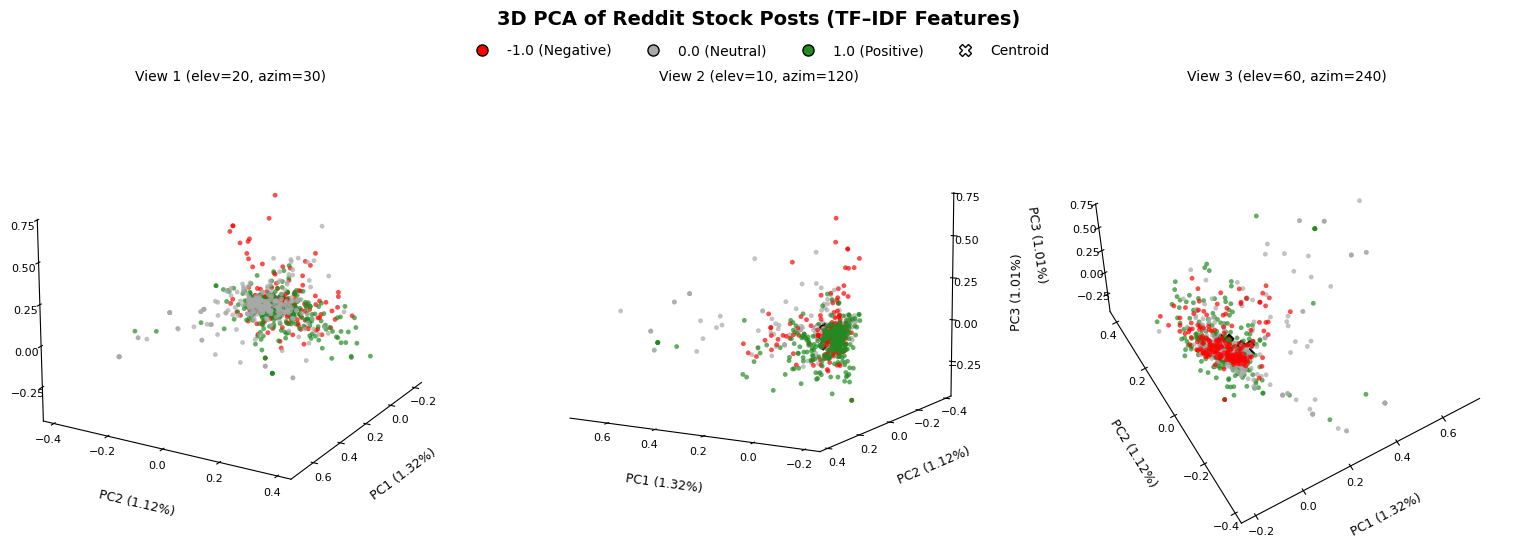

In [55]:
# --- SETUP: Load and Initial Preprocessing ---
import pandas as pd
import numpy as np
import re
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Standard Stopword List (using hardcoded list as in previous steps)
stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'])
stemmer = PorterStemmer()

def preprocess_text(text):
    """Financial-aware preprocessing: keeps '$', stems, removes stops."""
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|[^A-Za-z0-9\s$]', '', text).lower()
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

# Load Data
file_name = "Reddit-stock-sentiment.csv"
try:
    df = pd.read_csv(file_name, on_bad_lines='skip')
except FileNotFoundError:
    df = pd.read_csv("newdataset/" + file_name, on_bad_lines='skip')

df.columns = df.columns.str.lower().str.strip()
df_clean = df[['text', 'sentiment']].copy().dropna(subset=['text', 'sentiment'])
df_clean = df_clean.rename(columns={'sentiment': 'label'})
df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Prepare Labels
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
df_clean['label_numeric'] = df_clean['label'].map(label_map)
y_all = df_clean['label_numeric'].values
y_names = df_clean['label'].astype(str).values
target_names = ['-1.0 (Negative)', '0.0 (Neutral)', '1.0 (Positive)']
colors_list = ['red', 'darkgrey', 'forestgreen']

# --- 1️⃣ Build TF–IDF matrix ---
tfidf = TfidfVectorizer(max_features=5000, min_df=5)
X_tfidf = tfidf.fit_transform(df_clean['clean_text'])
print(f"✅ TF–IDF matrix shape: {X_tfidf.shape}")

# --- 2️⃣ Stratified Subsample for Visualization ---
def stratified_subsample(X, y_num, max_points=3000, seed=42):
    unique_labels, _ = np.unique(y_num, return_counts=True)
    if X.shape[0] <= max_points: return X, y_num
    
    rng = np.random.default_rng(seed)
    points_per_class = max(1, max_points // len(unique_labels))
    indices = []
    for label in unique_labels:
        class_indices = np.where(y_num == label)[0]
        size = min(points_per_class, len(class_indices))
        chosen = rng.choice(class_indices, size=size, replace=False)
        indices.append(chosen)
    final_indices = np.hstack(indices)
    
    return X[final_indices], y_num[final_indices]

X_plot, y_plot_num = stratified_subsample(X_tfidf, y_all, max_points=3000)
# Use original string labels for plotting mask
y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in X_plot.nonzero()[0]])
if len(y_plot_str) != X_plot.shape[0]: # Fallback for sparse matrix indexing complexity
     y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in df_clean.index[X_plot.nonzero()[0]]])
     if len(y_plot_str) != X_plot.shape[0]:
          # Simpler, less efficient fallback on original data indices
          df_sub = df_clean.loc[df_clean.index.isin(np.unique(X_plot.nonzero()[0]))]
          if len(df_sub) == 0:
              X_plot, y_plot_num = stratified_subsample(X_tfidf, y_all, max_points=3000)
              y_plot_str = np.array([str(df_clean['label'].iloc[i]) for i in np.where(np.in1d(y_all, y_plot_num))[0][:X_plot.shape[0]]])


# --- 3️⃣ Reduce to 3D via PCA ---
pca = PCA(n_components=3, random_state=42)
X_dense_plot = X_plot.toarray()
X_pca = pca.fit_transform(X_dense_plot)
var_explained = pca.explained_variance_ratio_ * 100

# --- 4️⃣ Assign colors and Centroids for each sentiment ---
unique_labels = np.unique(y_plot_num)
label_to_color = {0: 'red', 1: 'darkgrey', 2: 'forestgreen'}
label_to_name = {0: '-1.0 (Negative)', 1: '0.0 (Neutral)', 2: '1.0 (Positive)'}

# Calculate Centroids
centroids = np.vstack([X_pca[y_plot_num == lbl].mean(axis=0) for lbl in unique_labels])
centroid_colors = [label_to_color[lbl] for lbl in unique_labels]

# --- 5️⃣ Function to plot three views (Enhanced) ---
def plot_3d_enhanced(points, y_num, title, var_explained, views=[(20,30), (10,120), (60,240)]):
    fig = plt.figure(figsize=(16, 5.5))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)

    for i, (elev, azim) in enumerate(views, start=1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        
        # Clean Aesthetics
        ax.xaxis.pane.set_alpha(0.0); ax.yaxis.pane.set_alpha(0.0); ax.zaxis.pane.set_alpha(0.0)
        ax.set_facecolor('white'); ax.grid(False)
        ax.tick_params(labelsize=8, pad=-2)
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]: axis.set_major_locator(MaxNLocator(5))

        # Scatter points and Centroids
        for lbl in unique_labels:
            mask = (y_plot_num == lbl)
            ax.scatter(points[mask, 0], points[mask, 1], points[mask, 2],
                       s=12, alpha=0.7, color=label_to_color[lbl], edgecolor="none")
        
        # Plot Centroids
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   s=150, c=centroid_colors, marker="X", linewidths=1.5, edgecolor="black", zorder=10)

        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"View {i} (elev={elev}, azim={azim})", fontsize=10, pad=8)
        
        # Label with Explained Variance
        ax.set_xlabel(f"PC1 ({var_explained[0]:.2f}%)", fontsize=9, labelpad=8)
        ax.set_ylabel(f"PC2 ({var_explained[1]:.2f}%)", fontsize=9, labelpad=8)
        ax.set_zlabel(f"PC3 ({var_explained[2]:.2f}%)", fontsize=9, labelpad=8)

    # Unified Legend
    handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=label_to_color[lbl],
                      markersize=8, label=label_to_name[lbl]) for lbl in unique_labels]
    handles.append(Line2D([0], [0], marker='X', color='k', markerfacecolor='none',
                          linestyle='none', markersize=9, label='Centroid'))
    fig.legend(handles=handles, loc="upper center", ncol=len(unique_labels) + 1,
               bbox_to_anchor=(0.5, 0.95), frameon=False, fontsize=10)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()

# 6️⃣ Plot the 3D PCA
plot_3d_enhanced(X_pca, y_plot_num, "3D PCA of Reddit Stock Posts (TF–IDF Features)", var_explained)